## Salary Model Validation

In [1]:
from quant_slc_hedging.data_model import LoanModelInputs, SalaryModelInputs, SalaryGrowthType, salary_growth_amounts
from quant_slc_hedging.salary import SalaryModel
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
starting_salary=35_000
seed = 1234
years_remaining = 30
n_paths = 10_000

In [3]:
for growth_type, (rate, vol) in salary_growth_amounts.items():
    expected_salary = starting_salary * (1 + rate)**years_remaining
    print(f"For an expected rate of {rate * 100}% with vol of {vol * 100}% the expected salary is {expected_salary}")

For an expected rate of 1.0% with vol of 5.0% the expected salary is 47174.71203665171
For an expected rate of 2.5% with vol of 7.000000000000001% the expected salary is 73414.86526786251
For an expected rate of 4.0% with vol of 10.0% the expected salary is 113518.91285096396


## Check the average of the paths convergers to expected salary

In [4]:
results = []

for growth_type, (annual_growth, annual_vol) in salary_growth_amounts.items():

    config = SalaryModelInputs(
        starting_salary=starting_salary,
        salary_growth_dist=SalaryGrowthType(
            growth_type=growth_type
        ),
    )

    rng = np.random.default_rng(seed)

    model = SalaryModel(
        config=config,
        rng_gen=rng,
        freq="annual"
    )

    salary_paths = model.generate_salary_paths(
        n_paths=n_paths,
        n_months=12 * years_remaining,
    )

    for year in [1, 5, 10, 20, 30]:

        month = year * 12

        simulated_mean = salary_paths[:, month-1].mean()
        theoretical_mean = (
            starting_salary
            * (1 + annual_growth) ** year
        )

        results.append({
            "Growth Type": growth_type,
            "Year": year,
            "Simulated Mean": simulated_mean,
            "Theoretical Mean": theoretical_mean,
            "Difference": simulated_mean - theoretical_mean,
            "Difference %": (
                simulated_mean / theoretical_mean - 1
            ),
        })

results_df = pd.DataFrame(results)

In [5]:
results_df

,Growth Type,Year,Simulated Mean,Theoretical Mean,Difference,Difference %
0,Low,1,35377.989533,35350.000000,27.989533,0.000792
1,Low,5,36828.557287,36785.351754,43.205533,0.001175
2,Low,10,38710.357274,38661.774389,48.582885,0.001257
3,Low,20,42832.506941,42706.651398,125.855542,0.002947
4,Low,30,47245.729478,47174.712037,71.017441,0.001505
5,Medium,1,35914.237627,35875.000000,39.237627,0.001094
6,Medium,5,39665.102482,39599.287451,65.815031,0.001662
7,Medium,10,44879.821851,44802.959047,76.862804,0.001716
8,Medium,20,57600.396526,57351.575410,248.821116,0.004339
9,Medium,30,73598.815762,73414.865268,183.950494,0.002506


## Check convergence as n_paths increases

In [6]:
results = []
n_paths = [10_000, 25_000, 50_000, 100_000]

for n_path in n_paths:

    config = SalaryModelInputs(
        starting_salary=starting_salary,
        salary_growth_dist=SalaryGrowthType(
            growth_type="Medium"
        ),
    )
    annual_growth, annual_vol = salary_growth_amounts[config.salary_growth_dist.growth_type]

    rng = np.random.default_rng(seed)

    model = SalaryModel(
        config=config,
        rng_gen=rng,
        freq="monthly"
    )

    salary_paths = model.generate_salary_paths(
        n_paths=n_path,
        n_months=12 * years_remaining,
    )

    simulated_mean = salary_paths[:, -1].mean()
    theoretical_mean = starting_salary * (1+ annual_growth)**years_remaining
    results.append({
        "N_paths": n_path,
        "Simulated mean": simulated_mean,
        "Theoretical mean": theoretical_mean,
        "Error": abs(theoretical_mean - simulated_mean)

    })

results_df = pd.DataFrame(results)

In [7]:
results_df

,N_paths,Simulated mean,Theoretical mean,Error
0,10000,73746.751106,73414.865268,331.885838
1,25000,73336.328224,73414.865268,78.537044
2,50000,73362.373443,73414.865268,52.491825
3,100000,73389.569427,73414.865268,25.295841


In [8]:
config = SalaryModelInputs(
    starting_salary=35_000,
    salary_growth_dist=SalaryGrowthType(growth_type='Medium')
)

rng = np.random.default_rng(seed)

model = SalaryModel(
    config=config,
    rng_gen=rng,
    freq="annual"
)

salary_paths = model.generate_salary_paths(
    n_paths=10_000,
    n_months=12 * years_remaining,
)

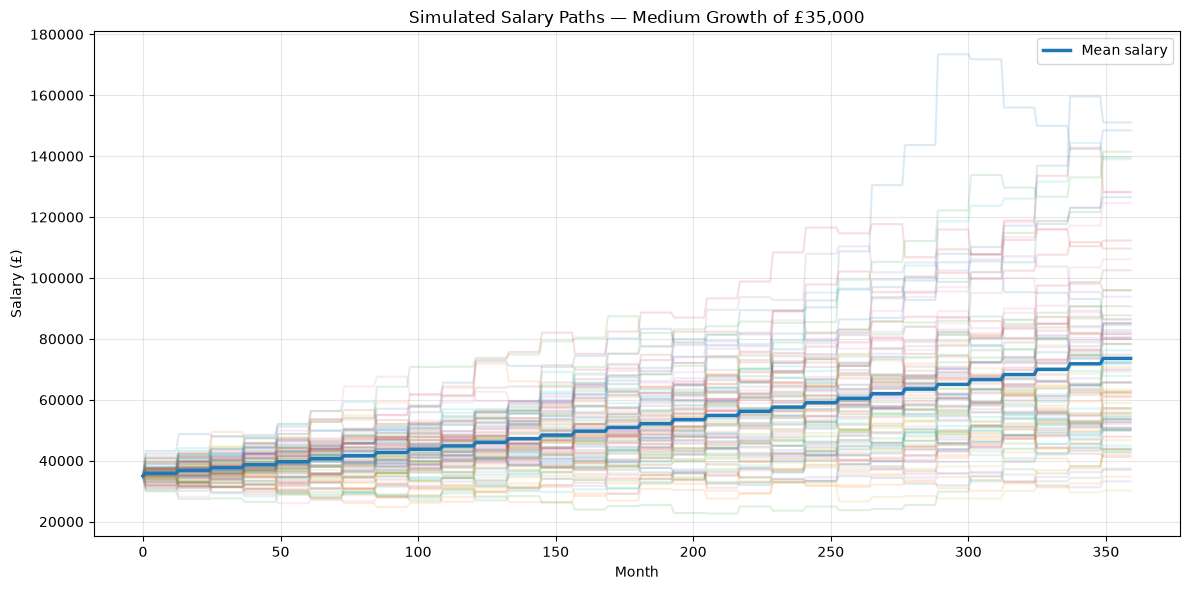

In [9]:
import numpy as np
import matplotlib.pyplot as plt

n_paths_to_plot = 100
months = np.arange(salary_paths.shape[1])

plt.figure(figsize=(12, 6))

for i in range(n_paths_to_plot):
    plt.plot(months, salary_paths[i], alpha=0.15)

# Add the mean salary path
mean_salary = salary_paths.mean(axis=0)
plt.plot(
    months,
    mean_salary,
    linewidth=2.5,
    label="Mean salary"
)

plt.xlabel("Month")
plt.ylabel("Salary (£)")
plt.title("Simulated Salary Paths — Medium Growth of £35,000")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()